MLP Neural Network - Phishing Site Detection

AI: In this notebook I train a Multi-Layer Perceptron neural network to detect phishing URLs. Compared to the baseline I used a bigger sample (100,000 rows), a deeper network with 3 hidden layers, and I added sample weights to deal with the class imbalance.

Import Libraries

In [1]:
import os
import re
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neural_network import MLPClassifier
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)

Configuration

In [2]:
CONFIG = {
    "data_path":           "../preprocessing-dataset/processed_data.csv",
    "result_dir":          "result",
    "url_column":          "URL",
    "text_column":         "processed_text",
    "label_column":        "Label",
    "sample_size":         100_000,
    "test_size":           0.2,
    "random_state":        42,
    "svd_components":      200,
    "hidden_layer_sizes":  (256, 128, 64),
    "activation":          "relu",
    "solver":              "adam",
    "max_iter":            500,
    "early_stopping":      True,
    "validation_fraction": 0.1,
}

os.makedirs(CONFIG["result_dir"], exist_ok=True)

Load the Data

In [3]:
df = pd.read_csv(CONFIG["data_path"])
print(f"Full dataset shape: {df.shape}")

df = df.sample(n=CONFIG["sample_size"], random_state=CONFIG["random_state"]).reset_index(drop=True)
print(f"Sampled dataset shape: {df.shape}")
print(f"Label distribution:\n{df[CONFIG['label_column']].value_counts()}")
df.head()

Full dataset shape: (549346, 3)
Sampled dataset shape: (100000, 3)
Label distribution:
Label
good    71629
bad     28371
Name: count, dtype: int64


,URL,Label,processed_text
0,tubevector.com/search/?q=erika,good,tubevector com search q erika
1,classmates.com/directory/school/Marian%20Chris...,good,classmat com directori school marian 20christi...
2,isgsi.com/office/adb/c58c94eccbfb951bd4ba5f2a6...,bad,isgsi com offic adb c58c94eccbfb951bd4ba5f2a62...
3,manufacturersnews.com/executives.asp?start=CEN,good,manufacturersnew com execut asp start cen
4,'9d345009-a-62cb3a1a-s-sites.googlegroups.com/...,bad,9d345009 a 62cb3a1a s site googlegroup com sit...


URL Features

AI : I extract 6 features from each raw URL. These features describe the structure of the URL, like its length, how many dots it has, and if it looks like an IP address. I do this before splitting so both train and test sets get the same features.

In [4]:
def extract_url_features(url: str) -> list[float]:
    """Extract 6 structural features from a raw URL string.

    Args:
        url: Raw URL string.

    Returns:
        A list of 6 numeric features:
        [url_length, num_dots, num_digits, num_special, has_ip, subdomain_depth].
    """
    url = str(url)
    subdomain_depth = max(0, len(url.split('/')[2].split('.')) - 2) if '//' in url else 0
    return [
        len(url),
        url.count('.'),
        sum(c.isdigit() for c in url),
        sum(c in '@-_=?&' for c in url),
        1 if re.search(r'\d+\.\d+\.\d+\.\d+', url) else 0,
        subdomain_depth,
    ]


url_features = np.array(
    [extract_url_features(u) for u in df[CONFIG["url_column"]]],
    dtype=np.float64,
)
print(f"URL feature matrix shape: {url_features.shape}")
print(f"Feature names: url_length, num_dots, num_digits, num_special, has_ip, subdomain_depth")
print(f"Sample row: {url_features[0]}")

URL feature matrix shape: (100000, 6)
Feature names: url_length, num_dots, num_digits, num_special, has_ip, subdomain_depth
Sample row: [30.  1.  0.  2.  0.  0.]


Labels and Split the Data
convert the labels from text (bad, good) to numbers using "LabelEncoder". Then I do an 80/20 random split. I split by index so the text, URL features, and labels all match.

In [5]:
le = LabelEncoder()
y = le.fit_transform(df[CONFIG["label_column"]].values)
print(f"Classes (encoded): {dict(zip(le.classes_, le.transform(le.classes_)))}")

idx = np.arange(len(df))
train_idx, test_idx = train_test_split(
    idx,
    test_size=CONFIG["test_size"],
    random_state=CONFIG["random_state"],
    stratify=y,
)

texts_train = df[CONFIG["text_column"]].iloc[train_idx].fillna("").astype(str).values
texts_test  = df[CONFIG["text_column"]].iloc[test_idx].fillna("").astype(str).values
url_train   = url_features[train_idx]
url_test    = url_features[test_idx]
y_train     = y[train_idx]
y_test      = y[test_idx]

print(f"Training samples: {len(train_idx)}")
print(f"Test samples:     {len(test_idx)}")

Classes (encoded): {'bad': np.int64(0), 'good': np.int64(1)}
Training samples: 80000
Test samples:     20000


TF-IDF Vectorization

AI: I fit a new `TfidfVectorizer` on the training text only. I do not use the old vectorizer file because that was fitted on all data which causes leakage.

In [6]:
tfidf = TfidfVectorizer()
X_train_tfidf = tfidf.fit_transform(texts_train)
X_test_tfidf  = tfidf.transform(texts_test)

print(f"TF-IDF vocabulary size: {len(tfidf.vocabulary_)}")
print(f"Train TF-IDF shape:     {X_train_tfidf.shape}")
print(f"Test  TF-IDF shape:     {X_test_tfidf.shape}")

TF-IDF vocabulary size: 112298
Train TF-IDF shape:     (80000, 112298)
Test  TF-IDF shape:     (20000, 112298)


Reduce Dimensions with SVD

AI : I use `TruncatedSVD` to compress the TF-IDF matrix to 200 dimensions. It is fitted on training data only.

In [7]:
svd = TruncatedSVD(n_components=CONFIG["svd_components"], random_state=CONFIG["random_state"])
X_train_svd = svd.fit_transform(X_train_tfidf)
X_test_svd  = svd.transform(X_test_tfidf)

explained = svd.explained_variance_ratio_.sum()
print(f"SVD output shape: {X_train_svd.shape}")
print(f"Explained variance ratio (cumulative): {explained:.3f}")

SVD output shape: (80000, 200)
Explained variance ratio (cumulative): 0.161


Combine the Features

AI : I join the 200 SVD columns and 6 URL features into one 206-column array using `np.hstack`.

In [8]:
X_train = np.hstack([X_train_svd, url_train])
X_test  = np.hstack([X_test_svd,  url_test])

print(f"Final train feature shape: {X_train.shape}")
print(f"Final test  feature shape: {X_test.shape}")

Final train feature shape: (80000, 206)
Final test  feature shape: (20000, 206)


Sample Weights
AI : The dataset has about 3 good URLs for every 1 bad URL. I use `compute_sample_weight` to give more importance to the bad class during training so the model does not just learn to always predict good.

In [9]:
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

classes, counts = np.unique(y_train, return_counts=True)
for cls, cnt in zip(le.classes_, counts):
    print(f"  {cls}: {cnt} samples, weight = {sample_weights[y_train == classes[list(le.classes_).index(cls)]][0]:.4f}")

  bad: 22697 samples, weight = 1.7623
  good: 57303 samples, weight = 0.6980


Train the Model

AI : I train the MLP with 3 hidden layers (256, 128, 64 neurons). I use early stopping so training stops when the model stops improving on the validation set. I also pass the sample weights to the fit function.

In [10]:
mlp = MLPClassifier(
    hidden_layer_sizes=CONFIG["hidden_layer_sizes"],
    activation=CONFIG["activation"],
    solver=CONFIG["solver"],
    max_iter=CONFIG["max_iter"],
    early_stopping=CONFIG["early_stopping"],
    validation_fraction=CONFIG["validation_fraction"],
    random_state=CONFIG["random_state"],
)
mlp.fit(X_train, y_train, sample_weight=sample_weights)
print("MLP Neural Network model trained.")
print(f"Number of iterations run: {mlp.n_iter_}")

MLP Neural Network model trained.
Number of iterations run: 62


Check the Results

In [11]:
y_pred = mlp.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {test_acc:.4f}")

Test accuracy: 0.9232


In [12]:
report = classification_report(y_test, y_pred, target_names=le.classes_)
print(report)

              precision    recall  f1-score   support

         bad       0.86      0.87      0.87      5674
        good       0.95      0.94      0.95     14326

    accuracy                           0.92     20000
   macro avg       0.90      0.91      0.91     20000
weighted avg       0.92      0.92      0.92     20000



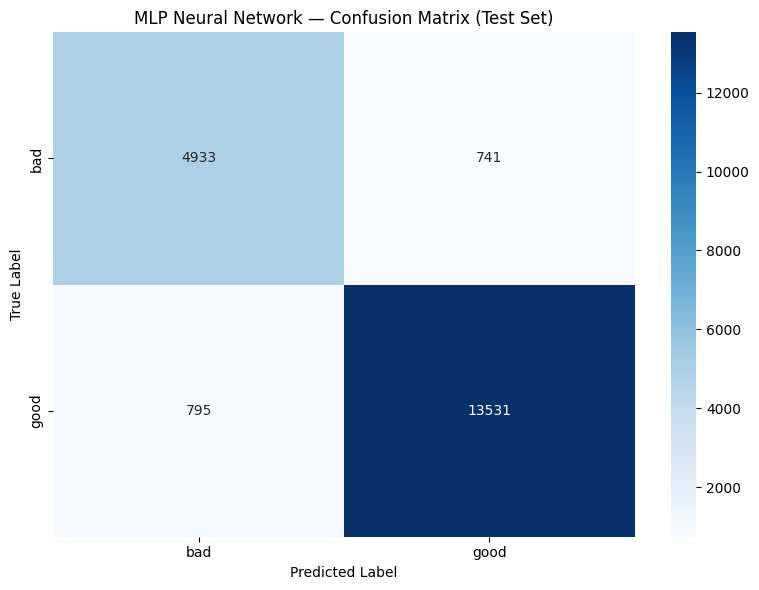

In [13]:
cm = confusion_matrix(y_test, y_pred)
labels = le.classes_

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    ax=ax,
)
ax.set_title("MLP Neural Network — Confusion Matrix (Test Set)")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
plt.tight_layout()
plt.show()

Save the Results

In [14]:
model_path = os.path.join(CONFIG["result_dir"], "model_mlp_nn.pkl")
with open(model_path, "wb") as f:
    pickle.dump(mlp, f)
print(f"Model saved to {model_path}")

Model saved to result\model_mlp_nn.pkl


In [15]:
report_path = os.path.join(CONFIG["result_dir"], "classification_report_mlp_nn.txt")
with open(report_path, "w") as f:
    f.write(f"Test accuracy: {test_acc:.4f}\n\n")
    f.write(report)
print(f"Classification report saved to {report_path}")

Classification report saved to result\classification_report_mlp_nn.txt


In [16]:
cm_path = os.path.join(CONFIG["result_dir"], "confusion_matrix_mlp_nn.png")
fig.savefig(cm_path, dpi=150, bbox_inches="tight")
print(f"Confusion matrix plot saved to {cm_path}")

Confusion matrix plot saved to result\confusion_matrix_mlp_nn.png
